# Clase 07 — Árboles de decisión (CART)
## Netflix — Churn y horas de visualización

---

Trabajamos como equipo de **Growth & Retention de Netflix LATAM**. Dos preguntas a responder:

1. ¿Quién se da de baja en los próximos 30 días? → **clasificación**.
2. ¿Cuántas horas va a ver el próximo mes? → **regresión**.

*Etapa de Modeling de CRISP-DM. La limpieza y transformación de datos se trabajaron en clases anteriores.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score,
)

sns.set_style("whitegrid")
ROJO, AZUL = "#E50914", "#221F1F"

---
## 1. Carga y vistazo


In [2]:
df = pd.read_csv("netflix_suscriptores.csv")

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1500 filas x 11 columnas


,antiguedad_meses,plan,horas_vistas_mes_pasado,perfiles_activos,genero_favorito,dispositivo_principal,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes
0,27,estandar,37.0,2,documental,pc,False,3,1,0,34.0
1,2,basico,6.9,1,anime,celular,True,6,0,1,3.3
2,40,premium,45.8,4,comedia,smart_tv,True,8,0,0,33.8
3,27,estandar,23.2,1,accion,celular,True,0,0,0,30.0
4,46,estandar_con_anuncios,17.7,1,reality,smart_tv,False,1,0,0,16.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   antiguedad_meses          1500 non-null   int64  
 1   plan                      1500 non-null   object 
 2   horas_vistas_mes_pasado   1500 non-null   float64
 3   perfiles_activos          1500 non-null   int64  
 4   genero_favorito           1500 non-null   object 
 5   dispositivo_principal     1500 non-null   object 
 6   usa_descargas_offline     1500 non-null   bool   
 7   dias_desde_ultima_sesion  1500 non-null   int64  
 8   cambios_plan_ultimo_anio  1500 non-null   int64  
 9   churn_30d                 1500 non-null   int64  
 10  horas_proximo_mes         1500 non-null   float64
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 118.8+ KB


**Variables:**

| Columna | Tipo | Qué representa |
|---|---|---|
| `antiguedad_meses` | num | meses desde que se suscribió |
| `plan` | cat | `basico` / `estandar` / `estandar_con_anuncios` / `premium` |
| `horas_vistas_mes_pasado` | num | horas vistas el mes anterior |
| `perfiles_activos` | num | cuántos perfiles del hogar se usaron |
| `genero_favorito` | cat | el género más visto |
| `dispositivo_principal` | cat | dónde mira más |
| `usa_descargas_offline` | bool | si usa la feature de descargar contenido |
| `dias_desde_ultima_sesion` | num | recencia |
| `cambios_plan_ultimo_anio` | num | señal de insatisfacción |
| **`churn_30d`** | target clasif | 1 = se dio de baja en 30 días |
| **`horas_proximo_mes`** | target reg | horas vistas el mes siguiente |

---
## 2. EDA mínimo

Antes de modelar, una sola cosa que necesitamos saber: **¿cómo está balanceado el target?**

In [4]:
conteo = df["churn_30d"].value_counts()
proporcion = df["churn_30d"].value_counts(normalize=True).round(3)

print("Cantidad de suscriptores por clase:")
print(conteo)
print("\nProporción:")
print(proporcion)

Cantidad de suscriptores por clase:
churn_30d
0    1317
1     183
Name: count, dtype: int64

Proporción:
churn_30d
0    0.878
1    0.122
Name: proportion, dtype: float64


**12% son churners.** Es un dataset **desbalanceado** — sin compensación, el modelo aprende a predecir "todos se quedan" y el recall de Churn cae casi a cero. Por eso vamos a usar `class_weight="balanced"` cuando entrenemos el árbol.

El resto del EDA (consumo por plan, recencia, outliers) va a **Para casa** — hoy nos vamos directo a modelar.

---
## 3. De los datos al modelo

Solo dos pasos: **one-hot encoding** de las categóricas y **train/test split** estratificado. CART no necesita escalado.

In [5]:
df_modelo = pd.get_dummies(
    df,
    columns=["plan", "genero_favorito", "dispositivo_principal"],
    drop_first=True,
)
df_modelo["usa_descargas_offline"] = df_modelo["usa_descargas_offline"].astype(int)

print(f"Columnas después del one-hot: {df_modelo.shape[1]}")
df_modelo.head()

Columnas después del one-hot: 21


,antiguedad_meses,horas_vistas_mes_pasado,perfiles_activos,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes,plan_estandar,plan_estandar_con_anuncios,...,genero_favorito_anime,genero_favorito_comedia,genero_favorito_documental,genero_favorito_drama,genero_favorito_kids,genero_favorito_reality,dispositivo_principal_consola,dispositivo_principal_pc,dispositivo_principal_smart_tv,dispositivo_principal_tablet
0,27,37.0,2,0,3,1,0,34.0,True,False,...,False,False,True,False,False,False,False,True,False,False
1,2,6.9,1,1,6,0,1,3.3,False,False,...,True,False,False,False,False,False,False,False,False,False
2,40,45.8,4,1,8,0,0,33.8,False,False,...,False,True,False,False,False,False,False,False,True,False
3,27,23.2,1,1,0,0,0,30.0,True,False,...,False,False,False,False,False,False,False,False,False,False
4,46,17.7,1,0,1,0,0,16.0,False,True,...,False,False,False,False,False,True,False,False,True,False


In [6]:
features = [c for c in df_modelo.columns if c not in ["churn_30d", "horas_proximo_mes"]]

X = df_modelo[features]
y_clf = df_modelo["churn_30d"]
y_reg = df_modelo["horas_proximo_mes"]

X_train, X_test, yclf_train, yclf_test, yreg_train, yreg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")

Train: 1050 filas  |  Test: 450 filas


---
## 4. Parte A — Clasificación: ¿quién va a hacer churn?

Árbol con profundidad limitada para que las reglas sean legibles. `class_weight="balanced"` porque solo el 12% son churners.

In [7]:
arbol_clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42,
)
arbol_clf.fit(X_train, yclf_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=15, random_state=42)

In [8]:
yclf_pred = arbol_clf.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(yclf_test, yclf_pred))
print("\nReporte de clasificación:")
print(classification_report(yclf_test, yclf_pred, target_names=["Se queda", "Churn"]))

Matriz de confusión:
[[293 102]
 [ 15  40]]

Reporte de clasificación:
              precision    recall  f1-score   support

    Se queda       0.95      0.74      0.83       395
       Churn       0.28      0.73      0.41        55

    accuracy                           0.74       450
   macro avg       0.62      0.73      0.62       450
weighted avg       0.87      0.74      0.78       450



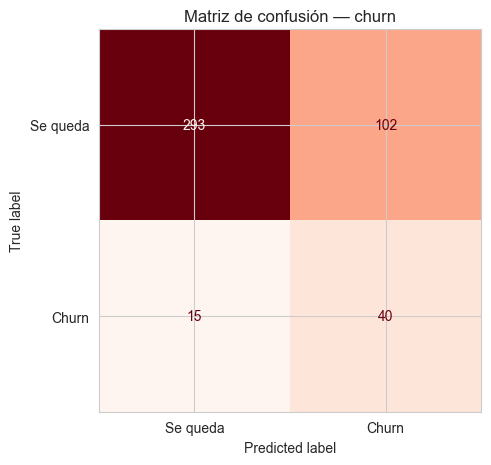

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(
    arbol_clf, X_test, yclf_test,
    display_labels=["Se queda", "Churn"],
    cmap="Reds", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — churn")
plt.tight_layout()
plt.show()

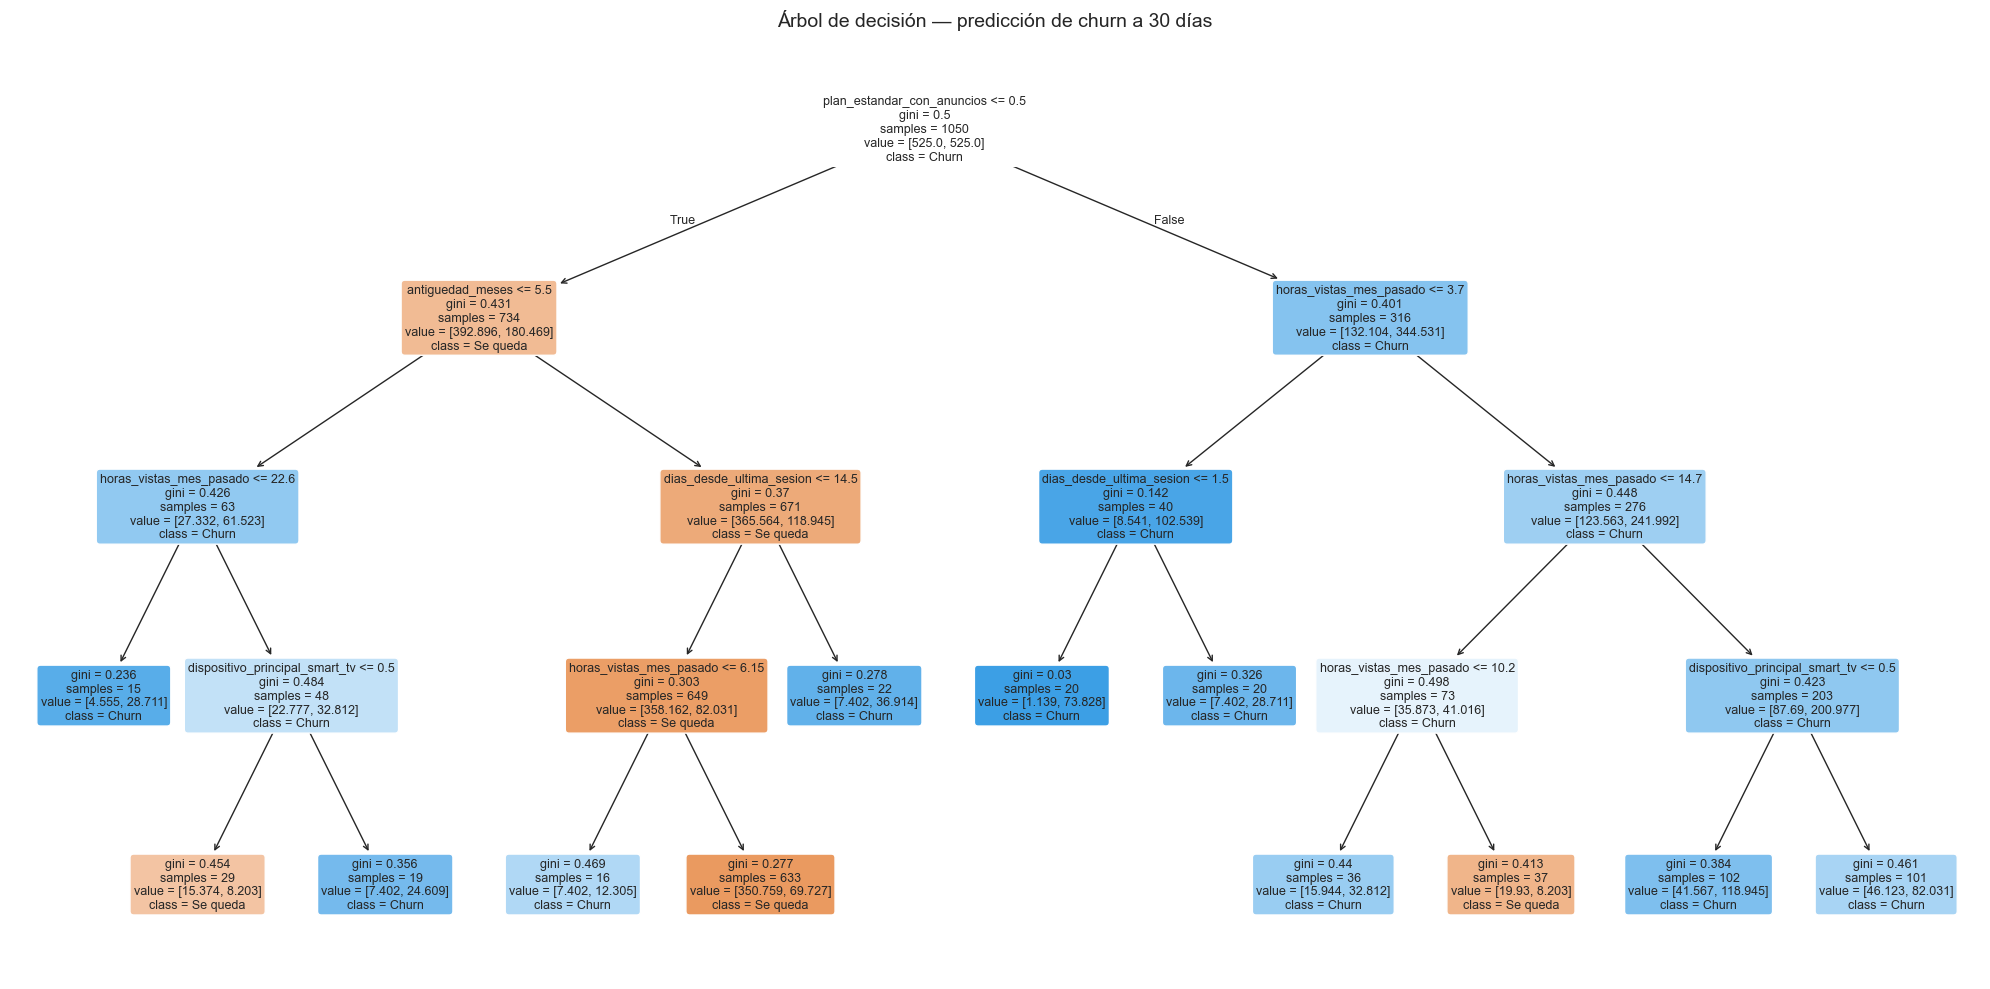

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    arbol_clf,
    feature_names=features,
    class_names=["Se queda", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Árbol de decisión — predicción de churn a 30 días", fontsize=14)
plt.tight_layout()
plt.show()

**Lectura del árbol:**

- El primer corte lo define `dias_desde_ultima_sesion`: **la recencia es el predictor más fuerte**.
- Las hojas más oscuras del lado Churn son los segmentos prioritarios para el equipo de Retention.

---
## 5. Parte B — Regresión: ¿cuántas horas va a ver?

Mismo árbol, target continuo: `DecisionTreeRegressor`. Cambia la métrica interna (MSE en vez de Gini) y la salida (un valor numérico por hoja en vez de una clase).

In [11]:
arbol_reg = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=30,
    random_state=42,
)
arbol_reg.fit(X_train, yreg_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=42)

In [12]:
yreg_pred = arbol_reg.predict(X_test)

mse = mean_squared_error(yreg_test, yreg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yreg_test, yreg_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f} horas")
print(f"R2:   {r2:.3f}")

MSE:  115.93
RMSE: 10.77 horas
R2:   0.712


**Visualicemos el árbol de regresión.** Cada hoja es un segmento de consumo con un valor esperado de horas para el próximo mes.

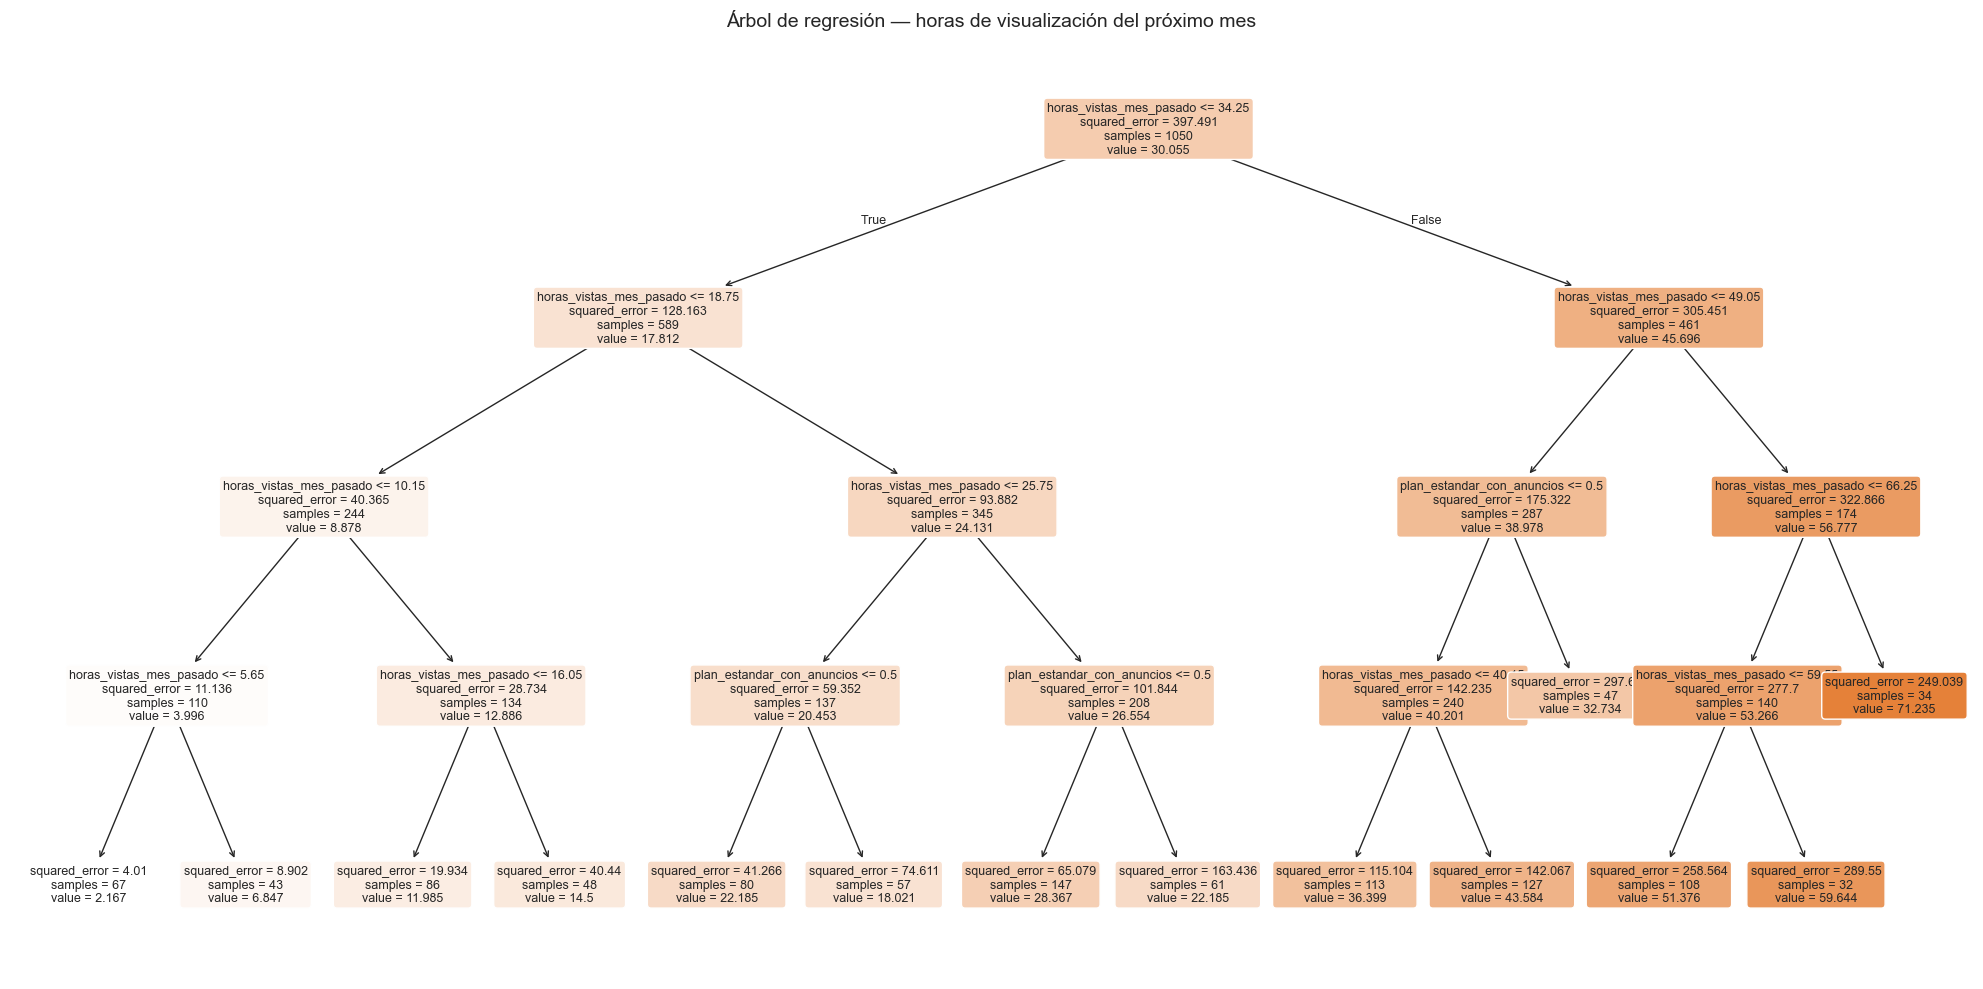

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    arbol_reg,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Árbol de regresión — horas de visualización del próximo mes", fontsize=14)
plt.tight_layout()
plt.show()

Las hojas son insumo directo para el cálculo de **LTV por segmento** y para que el equipo de Contenido sepa cuántas horas-vista empujar en cada cohorte.

---
## 6. Predicción operativa — 5 suscriptores nuevos

Para cada usuario nuevo, obtenemos `(prob_churn, horas_esperadas)` y la acción a tomar.

In [14]:
nuevos = pd.DataFrame([
    {"antiguedad_meses": 3,  "plan": "estandar_con_anuncios", "horas_vistas_mes_pasado": 4,   "perfiles_activos": 1, "genero_favorito": "reality",    "dispositivo_principal": "celular",  "usa_descargas_offline": False, "dias_desde_ultima_sesion": 22, "cambios_plan_ultimo_anio": 1},
    {"antiguedad_meses": 48, "plan": "premium",               "horas_vistas_mes_pasado": 60,  "perfiles_activos": 4, "genero_favorito": "drama",      "dispositivo_principal": "smart_tv", "usa_descargas_offline": True,  "dias_desde_ultima_sesion": 1,  "cambios_plan_ultimo_anio": 0},
    {"antiguedad_meses": 12, "plan": "estandar",              "horas_vistas_mes_pasado": 28,  "perfiles_activos": 2, "genero_favorito": "comedia",    "dispositivo_principal": "smart_tv", "usa_descargas_offline": True,  "dias_desde_ultima_sesion": 5,  "cambios_plan_ultimo_anio": 0},
    {"antiguedad_meses": 2,  "plan": "basico",                "horas_vistas_mes_pasado": 8,   "perfiles_activos": 1, "genero_favorito": "anime",      "dispositivo_principal": "celular",  "usa_descargas_offline": False, "dias_desde_ultima_sesion": 18, "cambios_plan_ultimo_anio": 2},
    {"antiguedad_meses": 30, "plan": "premium",               "horas_vistas_mes_pasado": 90,  "perfiles_activos": 5, "genero_favorito": "documental", "dispositivo_principal": "smart_tv", "usa_descargas_offline": True,  "dias_desde_ultima_sesion": 0,  "cambios_plan_ultimo_anio": 0},
])

nuevos

,antiguedad_meses,plan,horas_vistas_mes_pasado,perfiles_activos,genero_favorito,dispositivo_principal,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio
0,3,estandar_con_anuncios,4,1,reality,celular,False,22,1
1,48,premium,60,4,drama,smart_tv,True,1,0
2,12,estandar,28,2,comedia,smart_tv,True,5,0
3,2,basico,8,1,anime,celular,False,18,2
4,30,premium,90,5,documental,smart_tv,True,0,0


In [15]:
def preparar_nuevos(df_nuevos, columnas_modelo):
    df_proc = pd.get_dummies(
        df_nuevos,
        columns=["plan", "genero_favorito", "dispositivo_principal"],
        drop_first=True,
    )
    df_proc["usa_descargas_offline"] = df_proc["usa_descargas_offline"].astype(int)
    df_proc = df_proc.reindex(columns=columnas_modelo, fill_value=0)
    return df_proc

nuevos_X = preparar_nuevos(nuevos, features)

prob_churn = arbol_clf.predict_proba(nuevos_X)[:, 1]
horas_pred = arbol_reg.predict(nuevos_X)

resultado = nuevos[["antiguedad_meses", "plan", "horas_vistas_mes_pasado", "dias_desde_ultima_sesion"]].copy()
resultado["prob_churn"] = prob_churn.round(2)
resultado["horas_proximo_mes"] = horas_pred.round(1)
resultado["accion_retention"] = np.where(
    prob_churn >= 0.5, "Contactar urgente",
    np.where(prob_churn >= 0.25, "Mandar promo", "No tocar")
)

resultado

,antiguedad_meses,plan,horas_vistas_mes_pasado,dias_desde_ultima_sesion,prob_churn,horas_proximo_mes,accion_retention
0,3,estandar_con_anuncios,4,22,0.67,2.2,Contactar urgente
1,48,premium,60,1,0.17,59.6,No tocar
2,12,estandar,28,5,0.17,28.4,No tocar
3,2,basico,8,18,0.86,6.8,Contactar urgente
4,30,premium,90,0,0.17,71.2,No tocar


---
## Para casa

Todo lo que sigue es complementario al modelo. Trabajalo con calma — material que puede entrar al parcial.

### 1. EDA — ¿quiénes churnean?

Antes del modelo, mirá cómo se distribuye el churn por plan y por consumo de horas. Te da intuición de qué señales va a aprovechar el árbol.

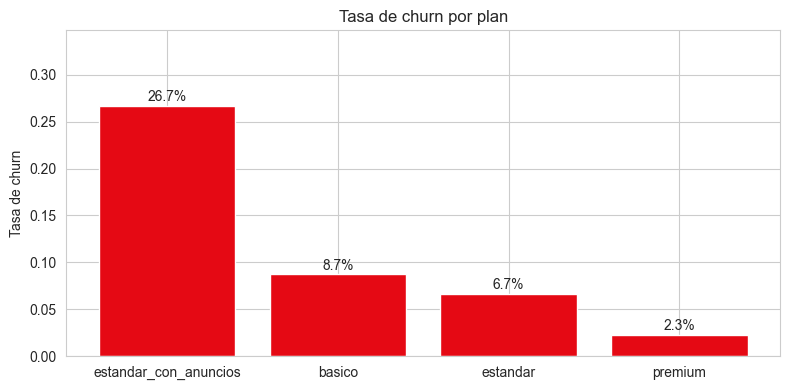

In [16]:
churn_por_plan = df.groupby("plan")["churn_30d"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(churn_por_plan.index, churn_por_plan.values, color=ROJO)
ax.set_ylabel("Tasa de churn")
ax.set_title("Tasa de churn por plan")
ax.set_ylim(0, churn_por_plan.max() * 1.3)
for i, v in enumerate(churn_por_plan.values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

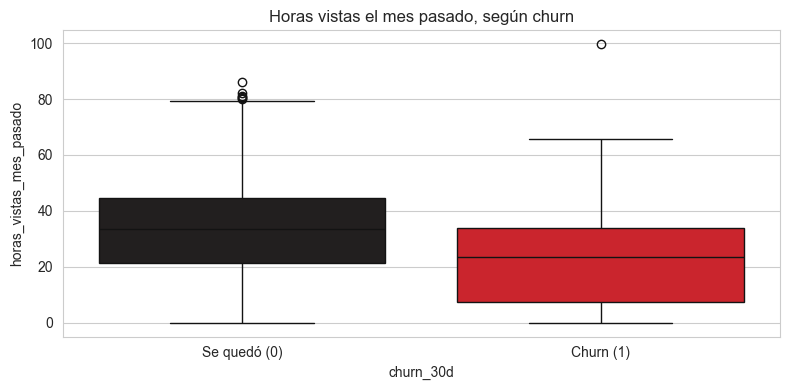

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="churn_30d", y="horas_vistas_mes_pasado",
            hue="churn_30d", palette=[AZUL, ROJO], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Se quedó (0)", "Churn (1)"])
ax.set_title("Horas vistas el mes pasado, según churn")
plt.tight_layout()
plt.show()

**Observaciones:**

- `estandar_con_anuncios` concentra la mayoría del churn.
- Los churners venían viendo menos horas.
- Los puntos altos del boxplot son binge-watchers reales (90+ horas/mes). **CART es robusto a outliers** porque corta por umbrales — no se remueven.

### 2. Recencia — segunda señal de churn

Días desde la última sesión. Es el predictor más fuerte (el árbol del modelo ya lo confirmó en la raíz).

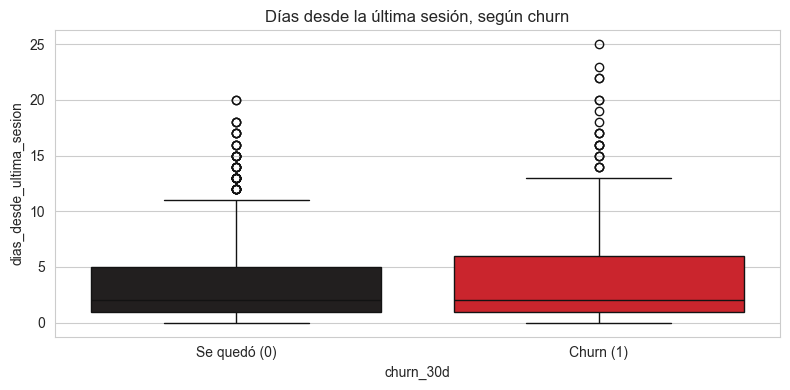

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="churn_30d", y="dias_desde_ultima_sesion",
            hue="churn_30d", palette=[AZUL, ROJO], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Se quedó (0)", "Churn (1)"])
ax.set_title("Días desde la última sesión, según churn")
plt.tight_layout()
plt.show()

### 3. Describe completo

Estadísticas de TODAS las variables.

In [19]:
df.describe(include="all").round(2)

,antiguedad_meses,plan,horas_vistas_mes_pasado,perfiles_activos,genero_favorito,dispositivo_principal,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes
count,1500.00,1500,1500.00,1500.00,1500,1500,1500,1500.00,1500.00,1500.00,1500.00
unique,NaN,4,NaN,NaN,7,5,2,NaN,NaN,NaN,NaN
top,NaN,estandar_con_anuncios,NaN,NaN,drama,smart_tv,False,NaN,NaN,NaN,NaN
freq,NaN,449,NaN,NaN,327,680,916,NaN,NaN,NaN,NaN
mean,29.78,NaN,32.40,1.93,NaN,NaN,NaN,3.54,0.48,0.12,30.34
std,16.70,NaN,17.36,1.00,NaN,NaN,NaN,3.96,0.77,0.33,19.98
min,1.00,NaN,0.00,1.00,NaN,NaN,NaN,0.00,0.00,0.00,0.00
25%,15.00,NaN,19.40,1.00,NaN,NaN,NaN,1.00,0.00,0.00,14.50
50%,29.00,NaN,32.20,2.00,NaN,NaN,NaN,2.00,0.00,0.00,29.45
75%,44.00,NaN,43.92,2.00,NaN,NaN,NaN,5.00,1.00,0.00,43.50


### 4. Reglas del árbol en texto

`export_text` devuelve el árbol como manual operativo plano, listo para copiar a un documento.

In [20]:
reglas = export_text(arbol_clf, feature_names=features)
print(reglas)

|--- plan_estandar_con_anuncios <= 0.50
|   |--- antiguedad_meses <= 5.50
|   |   |--- horas_vistas_mes_pasado <= 22.60
|   |   |   |--- class: 1
|   |   |--- horas_vistas_mes_pasado >  22.60
|   |   |   |--- dispositivo_principal_smart_tv <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- dispositivo_principal_smart_tv >  0.50
|   |   |   |   |--- class: 1
|   |--- antiguedad_meses >  5.50
|   |   |--- dias_desde_ultima_sesion <= 14.50
|   |   |   |--- horas_vistas_mes_pasado <= 6.15
|   |   |   |   |--- class: 1
|   |   |   |--- horas_vistas_mes_pasado >  6.15
|   |   |   |   |--- class: 0
|   |   |--- dias_desde_ultima_sesion >  14.50
|   |   |   |--- class: 1
|--- plan_estandar_con_anuncios >  0.50
|   |--- horas_vistas_mes_pasado <= 3.70
|   |   |--- dias_desde_ultima_sesion <= 1.50
|   |   |   |--- class: 1
|   |   |--- dias_desde_ultima_sesion >  1.50
|   |   |   |--- class: 1
|   |--- horas_vistas_mes_pasado >  3.70
|   |   |--- horas_vistas_mes_pasado <= 14.70
|   |   |   

### 5. Importancia de variables

Cuánto pesa cada feature en los cortes del árbol — la versión cuantitativa de lo que se ve en el árbol visual.

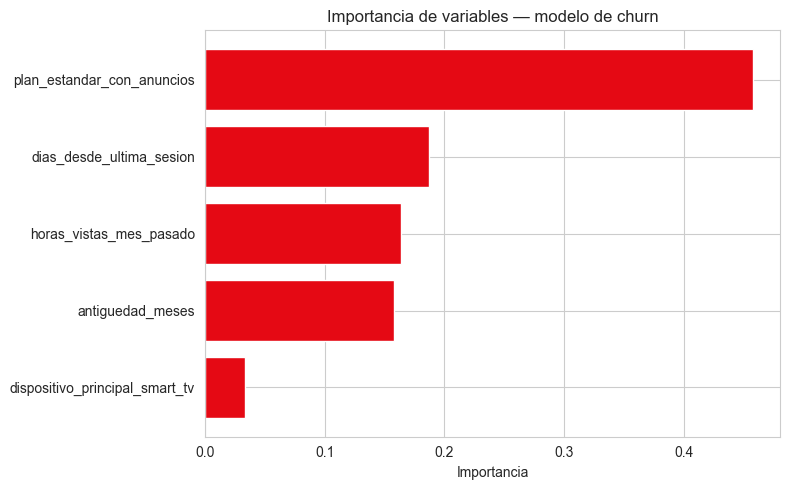

In [21]:
importancias = pd.Series(arbol_clf.feature_importances_, index=features).sort_values(ascending=True)
importancias = importancias[importancias > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias.index, importancias.values, color=ROJO)
ax.set_title("Importancia de variables — modelo de churn")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

### 6. Predicho vs real

Diagnóstico visual del regresor: puntos cerca de la diagonal = buena predicción. La desviación es el error.

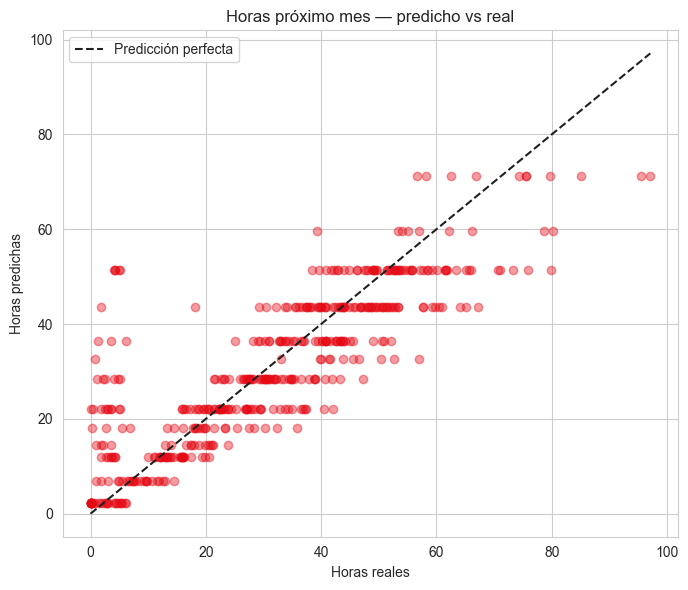

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(yreg_test, yreg_pred, alpha=0.4, color=ROJO)
max_h = max(yreg_test.max(), yreg_pred.max())
ax.plot([0, max_h], [0, max_h], "--", color=AZUL, label="Predicción perfecta")
ax.set_xlabel("Horas reales")
ax.set_ylabel("Horas predichas")
ax.set_title("Horas próximo mes — predicho vs real")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Cierre

**Qué hicimos:**

| Pregunta | Target | Modelo | Métrica principal |
|---|---|---|---|
| ¿Quién churnea? | `churn_30d` (0/1) | `DecisionTreeClassifier` | Recall de Churn |
| ¿Cuántas horas? | `horas_proximo_mes` (continuo) | `DecisionTreeRegressor` | RMSE |

**Tres ideas para llevarse:**

1. **Un mismo algoritmo aplicado a dos problemas distintos.** Clasificación y regresión comparten la misma lógica de partición recursiva; sólo cambia la métrica de impureza (Gini para clases, MSE para valores continuos).
2. **Interpretabilidad como ventaja.** Cada predicción de un árbol está respaldada por una secuencia explícita de reglas. Es lo que diferencia a CART de Logística o KNN cuando el área de negocio pide explicaciones.
3. **Un árbol individual es limitado.** Profundidad pequeña tiende a subajustar, profundidad grande tiende a sobreajustar. La próxima clase aborda la solución industrial: combinar múltiples árboles (Random Forest, Gradient Boosting).